In [1]:
import os
from langchain_community.document_loaders import PyPDFLoader

docs = [
  r"..\document\SK_REKTOR_70_SK_Rektor_Tentang_Bentuk_Tugas.pdf",
  r"..\document\SK_REKTOR_1221_Pedoman_pengenalan_budaya_akad.pdf",
  r"..\document\SK_REKTOR_1280_Pedoman_Akademik_PROGRAM_SARJANA.pdf",
]

print("=" * 82)
print(f"{'Nama Dokumen':<55} | {'Hal':<6} | {'Total Karakter':<15}")
print("=" * 82)

for doc in docs:
  data = PyPDFLoader(doc).load()

  file_name = os.path.basename(doc) 
  total_pages = len(data)
  total_chars = sum(len(d.page_content) for d in data)

  print(f"{file_name:<55} | {total_pages:<6} | {total_chars:<15,}")

print("=" * 82)

C:\Users\labma\AppData\Local\Temp\ipykernel_15620\3749996064.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


Nama Dokumen                                            | Hal    | Total Karakter 
SK_REKTOR_70_SK_Rektor_Tentang_Bentuk_Tugas.pdf         | 3      | 7,158          
SK_REKTOR_1221_Pedoman_pengenalan_budaya_akad.pdf       | 26     | 44,486         
SK_REKTOR_1280_Pedoman_Akademik_PROGRAM_SARJANA.pdf     | 14     | 45,948         


In [4]:
import sys

sys.path.append("../")
from vector_db import vector_db

collections_name = ["fixed-chunk","recursive-chunk", "semantic-chunk"]

for name in collections_name:
  data = vector_db.get_vector_db(name).get()

  docs = data["documents"]
  total_chunk = len(docs)
  chunk_length = [len(doc) for doc in docs]

  min_len = min(chunk_length)
  max_len = max(chunk_length)
  avg_len = sum(chunk_length) / total_chunk

  print(f"\n📌 Chunk Method : {name.upper()}")
  print(f"   • Total Chunk    : {total_chunk:,}")
  print(f"   • Length Stats   : Min = {min_len} | Avg = {avg_len:.1f} | Max = {max_len} (karakter)")
  print("-" * 70)


📌 Chunk Method : FIXED-CHUNK
   • Total Chunk    : 432
   • Length Stats   : Min = 21 | Avg = 240.5 | Max = 256 (karakter)
----------------------------------------------------------------------

📌 Chunk Method : RECURSIVE-CHUNK
   • Total Chunk    : 460
   • Length Stats   : Min = 26 | Avg = 212.1 | Max = 254 (karakter)
----------------------------------------------------------------------

📌 Chunk Method : SEMANTIC-CHUNK
   • Total Chunk    : 96
   • Length Stats   : Min = 2 | Avg = 1012.8 | Max = 3568 (karakter)
----------------------------------------------------------------------


In [5]:
import sys
import pandas as pd

sys.path.append("../")
from vector_db import vector_db

collections_name = ["fixed-chunk", "recursive-chunk", "semantic-chunk"]

for name in collections_name:
  data = vector_db.get_vector_db(name).get()

  docs = data["documents"]
  metadatas = data["metadatas"]

  doc_names = [m.get("source", m.get("filename", "Unknown")) for m in metadatas]
  chunk_lengths = [len(doc) for doc in docs]

  df_temp = pd.DataFrame(
    {
      "document": doc_names,
      "chunk_length": chunk_lengths,
    }
  )

  print("=" * 70)
  print(f"📌 CHUNK METHOD : {name.upper()}")
  print("=" * 70)

  doc_summary = (
    df_temp.groupby("document")
    .agg(
      total_chunks=("chunk_length", "count"),
      min_len=("chunk_length", "min"),
      avg_len=("chunk_length", "mean"),
      max_len=("chunk_length", "max"),
    )
    .reset_index()
  )

  for _, row in doc_summary.iterrows():
    print(f"📄 Dokumen : {row['document']}")
    print(f"   • Total Chunk  : {row['total_chunks']:,}")
    print(
      f"   • Length Stats : Min = {row['min_len']} | Avg = {row['avg_len']:.1f} | Max = {row['max_len']} (karakter)"
    )
    print("-" * 70)
  print("\n")

📌 CHUNK METHOD : FIXED-CHUNK
📄 Dokumen : SK_REKTOR_1221_Pedoman_pengenalan_budaya_akad.pdf
   • Total Chunk  : 200
   • Length Stats : Min = 21 | Avg = 236.2 | Max = 256 (karakter)
----------------------------------------------------------------------
📄 Dokumen : SK_REKTOR_1280_Pedoman_Akademik_PROGRAM_SARJANA.pdf
   • Total Chunk  : 200
   • Length Stats : Min = 24 | Avg = 245.0 | Max = 256 (karakter)
----------------------------------------------------------------------
📄 Dokumen : SK_REKTOR_70_SK_Rektor_Tentang_Bentuk_Tugas.pdf
   • Total Chunk  : 32
   • Length Stats : Min = 33 | Avg = 239.0 | Max = 256 (karakter)
----------------------------------------------------------------------


📌 CHUNK METHOD : RECURSIVE-CHUNK
📄 Dokumen : SK_REKTOR_1221_Pedoman_pengenalan_budaya_akad.pdf
   • Total Chunk  : 207
   • Length Stats : Min = 26 | Avg = 215.9 | Max = 254 (karakter)
----------------------------------------------------------------------
📄 Dokumen : SK_REKTOR_1280_Pedoman_Akademik_P

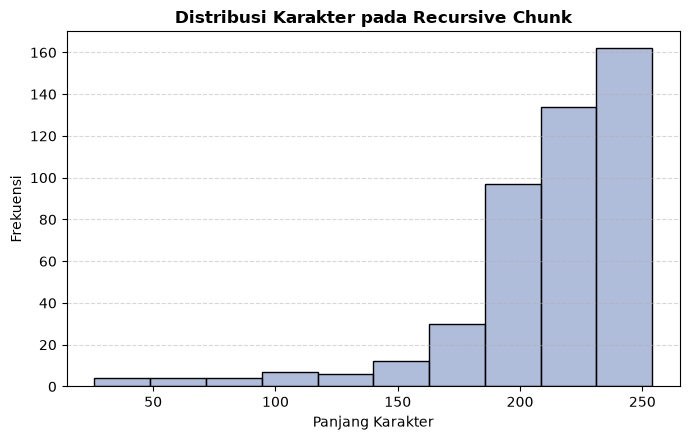

In [12]:
import sys
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.append("../")
from vector_db import vector_db

target_chunk = "recursive-chunk"

data = vector_db.get_vector_db(target_chunk).get()
chunk_lengths = [len(doc) for doc in data["documents"]]

df = pd.DataFrame({"chunk_length": chunk_lengths})

plt.figure(figsize=(7, 4.5))
sns.histplot(
  data=df,
  x="chunk_length",
  color="#8da0cb",
  bins=10,
  edgecolor="black",
  alpha=0.7,
)

plt.title(f"Distribusi Karakter pada {target_chunk.replace("-", " ").title()}", fontsize=12, fontweight="bold")
plt.xlabel("Panjang Karakter")
plt.ylabel("Frekuensi")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

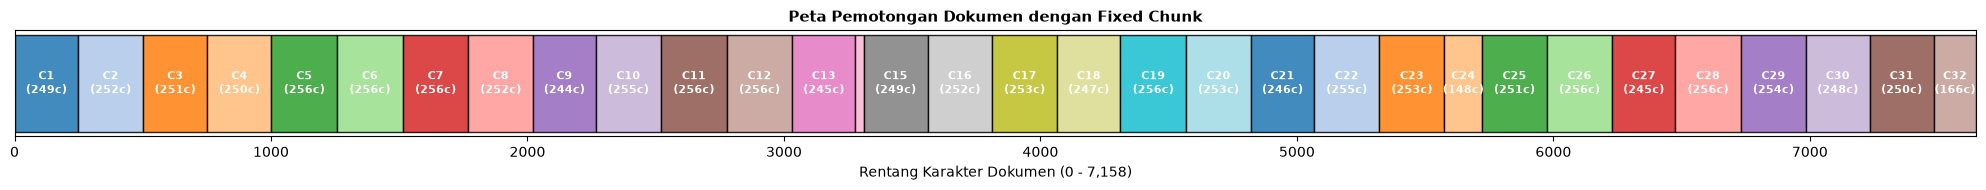

In [11]:
import sys
import matplotlib.pyplot as plt
from langchain_community.document_loaders import PyPDFLoader

sys.path.append("../")
from vector_db import vector_db

collection_name = "fixed-chunk"
document_path = "../document/SK_REKTOR_70_SK_Rektor_Tentang_Bentuk_Tugas.pdf"
db_source_key = "SK_REKTOR_70_SK_Rektor_Tentang_Bentuk_Tugas.pdf"

data = vector_db.get_vector_db(collection_name).get(
  where={"source": db_source_key}
)
chunk_lengths = [len(doc) for doc in data["documents"]]

pdf_docs = PyPDFLoader(document_path).load()
total_chars = sum(len(d.page_content) for d in pdf_docs)

plt.figure(figsize=(20, 2))
colors = plt.cm.tab20.colors

start = 0
for idx, length in enumerate(chunk_lengths):
  plt.barh(
    y="Dokumen",
    width=length,
    left=start,
    edgecolor="black",
    color=colors[idx % len(colors)],
    alpha=0.85,
  )

  if length > 50:
    plt.text(
      x=start + length / 2,
      y=0,
      s=f"C{idx+1}\n({length}c)",
      ha="center",
      va="center",
      color="white",
      fontsize=8,
      fontweight="bold",
    )
  start += length

plt.xlim(0, max(total_chars, start))
plt.title(
  f"Peta Pemotongan Dokumen dengan {collection_name.replace("-", " ").title()}",
  fontsize=11,
  fontweight="bold",
)
plt.xlabel(f"Rentang Karakter Dokumen (0 - {total_chars:,})")
plt.yticks([]) 
plt.tight_layout()
plt.show()